In [2]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#with open ("CovidTravelProject/US_Covid_and_Travel_Data.csv", "rb") as f:
    #CovidTravelDF = pickle.load(f)

CovidTravelDF = pd.read_csv("US_Covid_and_Travel_Data.csv")

CovidTravelDF.head()

,Year,Month_number,Month,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Foreign_originating,Foreign_returning,US_citizen_originating,US_citizen_returning,Timestamp
0,2020,1,January,8,8,0,0,5274405,5520357,4073096,5218812,2020-01
1,2020,2,February,61,69,1,1,4470729,4448720,3902937,4155775,2020-02
2,2020,3,March,173074,173143,3326,3327,1960896,2946059,1844726,3053096,2020-03
3,2020,4,April,857163,1030306,57134,60461,54031,176627,32144,110285,2020-04
4,2020,5,May,755116,1785422,44864,105325,78337,192614,54368,107630,2020-05


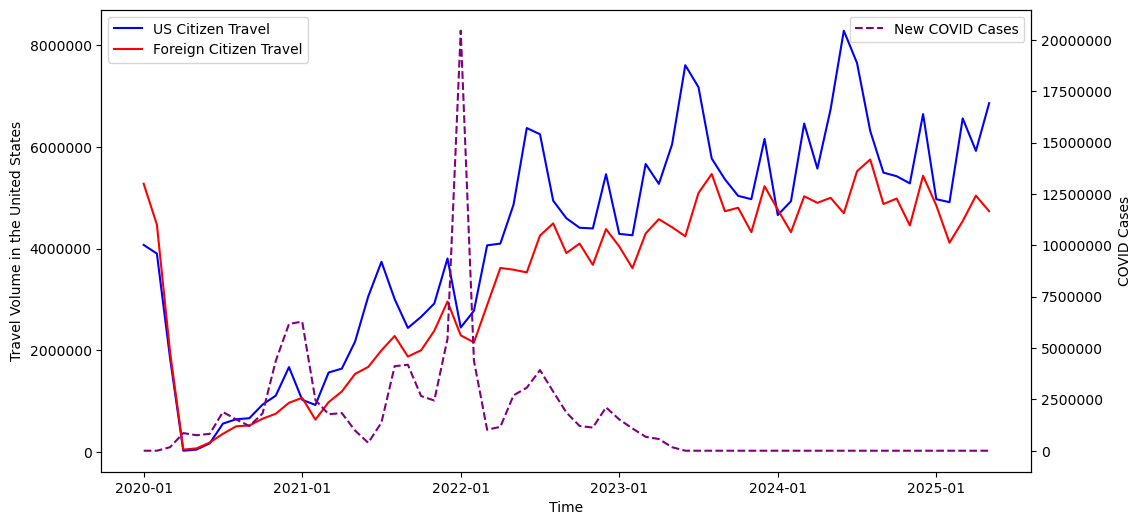

In [19]:
f, ax1 = plt.subplots(figsize = (12,6))

sns.lineplot(data=CovidTravelDF, x="Timestamp", y="US_citizen_originating", ax=ax1, color="blue", label="US Citizen Travel", errorbar=None)
sns.lineplot(data=CovidTravelDF, x="Timestamp", y="Foreign_originating", ax=ax1, color="red", label="Foreign Citizen Travel", errorbar=None)

ax1.set_ylabel("Travel Volume in the United States")
ax1.set_xlabel("Time")

ax2 = ax1.twinx()
sns.lineplot(data=CovidTravelDF, x="Timestamp", y="New_cases", ax=ax2, color="purple", linestyle = "--", label="New COVID Cases", errorbar=None)

ax2.set_ylabel("COVID Cases")

ax1.set_xticks(ax1.get_xticks()[::12])

ax1.ticklabel_format(style='plain', axis='y')
ax2.ticklabel_format(style='plain', axis='y')



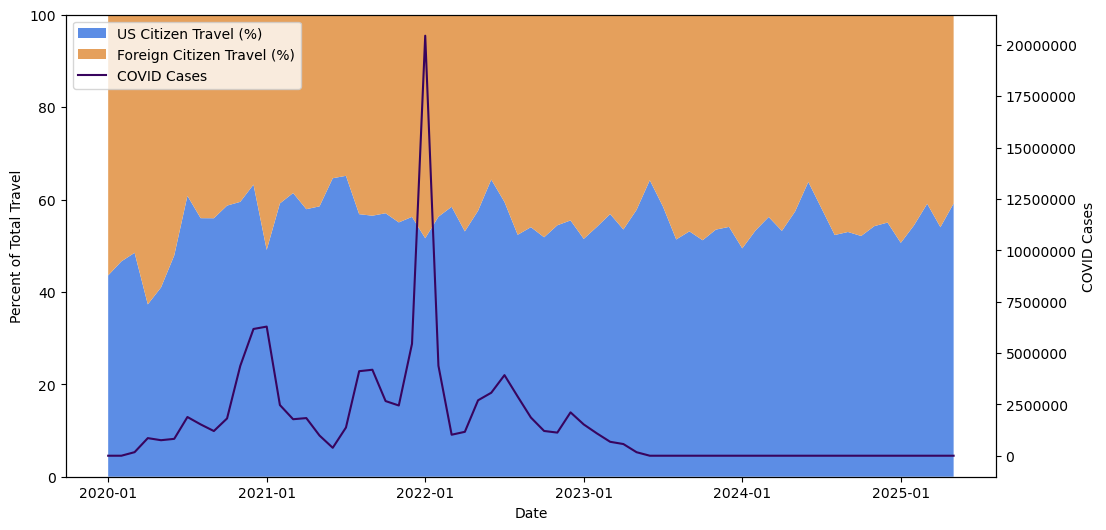

In [25]:
CovidTravelDF["Total_travel"] = CovidTravelDF["US_citizen_originating"] + CovidTravelDF["Foreign_originating"]
CovidTravelDF["US_percent"] = (CovidTravelDF["US_citizen_originating"]/CovidTravelDF["Total_travel"]) * 100
CovidTravelDF["Foreign_percent"] = (CovidTravelDF["Foreign_originating"]/CovidTravelDF["Total_travel"]) * 100

fig, ax1 = plt.subplots(figsize = (12,6))

ax1.stackplot(CovidTravelDF["Timestamp"],
              CovidTravelDF["US_percent"],
              CovidTravelDF["Foreign_percent"],
              labels = ["US Citizen Travel (%)", "Foreign Citizen Travel (%)"],
              colors = ["#5c8de5", "#e5a05c"])

ax1.set_ylabel("Percent of Total Travel")
ax1.set_xlabel("Date")
ax1.set_ylim(0,100)

ax2 = ax1.twinx()
ax2.plot(CovidTravelDF["Timestamp"], 
         CovidTravelDF["New_cases"],
         color = "#38045e",
         label = "COVID Cases")
ax2.set_ylabel("COVID Cases")

ax1.set_xticks(ax1.get_xticks()[::12])
ax1.ticklabel_format(style='plain', axis='y')
ax2.ticklabel_format(style='plain', axis='y')

travel_handles, travel_labels = ax1.get_legend_handles_labels()
covid_handles, covid_labels = ax2.get_legend_handles_labels()

ax1.legend(travel_handles + covid_handles,
           travel_labels + covid_labels,
           loc = "upper left")